<a href="https://colab.research.google.com/github/lenjulca100/SCRIPT-VARIOS/blob/main/Script_Monitoreo_fenologico_UP_FOREST_INNOVATION_INGENIERIA_Y_GESTION_SAC_pynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install earthengine-api geemap xarray xee rioxarray openpyxl -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 468.9/468.9 kB 8.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.7/62.7 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 22.3/22.3 MB 27.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 16.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 16.8 MB/s eta 0:00:00


In [2]:
# Importación de las librerías
import ee
import geemap
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import pandas as pd
import seaborn as sns
import numpy as np
import warnings

# Suprimir advertencias comunes de xarray/geopandas para una salida más limpia
warnings.filterwarnings("ignore")

from google.colab import auth
auth.authenticate_user()
# -----------------------------------------------------------------
# !! IMPORTANTE !!: Cambia 'ee-cajamarca01' por tu propio ID de proyecto de GEE
ee.Initialize(project='ee-cajamarca01')
# -----------------------------------------------------------------

In [3]:
# PASO 2: DEFINICIÓN DE LA ZONA DE INTERÉS ÚNICA
print("Definiendo el Área de Interés (AOI)...")

# Coordenadas para la Zona de Interés
coords_aoi = [
[-74.89651831965291,-8.329105913105165],
[-74.894372552441,-8.329615465021275],
[-74.89231261591756,-8.329190838470593],
[-74.89042434077108,-8.328766211459174],
[-74.88905104975545,-8.328511435031187],
[-74.88802108149373,-8.327832030412408],
[-74.88570365290487,-8.327492327660792],
[-74.88304290156209,-8.327407401926815],
[-74.88098296503865,-8.327237550403607],
[-74.87728153998141,-8.326982772980589],
[-74.87393414313082,-8.32630336570855],
[-74.87479245001559,-8.324604842370242],
[-74.87530743414645,-8.323246018394741],
[-74.87522160345797,-8.321037919379528],
[-74.87556492621188,-8.319679083029786],
[-74.87642323309665,-8.313903975976988],
[-74.87719570929293,-8.312460185920187],
[-74.8777106934238,-8.311356107584142],
[-74.87753903204684,-8.309572589860549],
[-74.87959896857028,-8.307109623483433],
[-74.88809620672946,-8.305241155919433],
[-74.89384686285739,-8.30761920400236],
[-74.89693676764254,-8.311186249102722],
[-74.89728009039645,-8.315772402275973],
[-74.89659344488864,-8.320783137922955],
[-74.89659344488864,-8.32451991600991],
[-74.89659344488864,-8.326558143573743],
[-74.89625012213473,-8.328086807282656],
[-74.89651831965291,-8.329105913105165]
]

aoi = ee.Geometry.Polygon(coords_aoi)
nombre_zona = "Zona_de_Interes_1" # Puedes cambiar este nombre

print(f"Polígono para '{nombre_zona}' creado.")

Definiendo el Área de Interés (AOI)...
Polígono para 'Zona_de_Interes_1' creado.


In [4]:
# PASO 3: DEFINICIÓN DE FUNCIONES DE PROCESAMIENTO
# ==============================================================================
def enmascarar_y_calcular_ndvi(img):
    """Enmascara nubes/sombras y calcula el NDVI para una imagen HLS S30."""
    qa_band = img.select('Fmask')
    cirrus = qa_band.bitwiseAnd(1 << 0).neq(0)
    cloud = qa_band.bitwiseAnd(1 << 1).neq(0)
    shadow = qa_band.bitwiseAnd(1 << 3).neq(0)
    mask = cirrus.Or(cloud).Or(shadow)
    ndvi = img.normalizedDifference(['B8', 'B4']).rename('ndvi')
    return ndvi.updateMask(mask.Not()).copyProperties(img, ['system:time_start'])


# PASO 4: FUNCIÓN PRINCIPAL DE ANÁLISIS Y EXPORTACIÓN
# ==============================================================================
def analizar_y_exportar(roi, nombre_zona):
    """
    Función principal que descarga datos, genera gráficos y exporta resultados
    para un ROI y nombre de zona dados.
    """

    # --- Configuración de Estilo de Gráficos ---
    # Se establece un tema visual más atractivo para todos los gráficos
    sns.set_theme(style="whitegrid", palette="viridis", font_scale=1.1)
    print(f"\n===== INICIANDO ANÁLISIS 2024-2025 PARA: {nombre_zona} =====")

    ee_collection = ee.ImageCollection('NASA/HLS/HLSS30/v002') \
                      .filterDate('2024-01-01', '2025-12-31') \
                      .filterBounds(roi) \
                      .map(enmascarar_y_calcular_ndvi)

    print(f"Descargando datos para {nombre_zona}...")
    try:
        ds = xr.open_dataset(ee_collection, engine='ee', crs='EPSG:4326', scale=0.0003, geometry=roi)
        ds = ds.sortby('time')
        if ds.time.size == 0:
            print("No se encontraron imágenes para el rango de fechas y la zona. Terminando análisis.")
            return
        print(f"Datos descargados: {ds.time.size} imágenes encontradas.")
    except Exception as e:
        print(f"No se pudieron descargar los datos. Error: {e}"); return

    # --- 1. GRÁFICO: Mapas Mensuales (Small Multiples) ---
    print("\n--- 1. Generando gráfico de mapas mensuales ---")
    ds_mensual = ds.resample(time='1M').mean()

    g = ds_mensual.ndvi.plot(x='lon', y='lat', col='time', col_wrap=6, cmap='RdYlGn',
                               robust=True, add_colorbar=False, size=4)
    fig = g.fig

    if g.axes.size > 0:
        fig.subplots_adjust(bottom=0.15, top=0.92)
        cbar_ax = fig.add_axes([0.25, 0.08, 0.5, 0.025])
        norm = colors.Normalize(vmin=0, vmax=1)
        sm = plt.cm.ScalarMappable(cmap='RdYlGn', norm=norm)
        cbar = fig.colorbar(sm, cax=cbar_ax, orientation='horizontal')
        cbar.set_label('NDVI Promedio Mensual', fontsize=12)
        for ax in g.axes.flat:
            ax.set_xlabel(""); ax.set_ylabel(""); ax.set_aspect('equal')
            try:
                timestamp = pd.Timestamp(ax.get_title().split('=')[-1].strip())
                ax.set_title(f"{timestamp.strftime('%b %Y')}", fontsize=12)
            except: ax.set_title("")
        g.set_axis_labels("Longitud", "Latitud")
        fig.suptitle(f'Evolución Mensual del NDVI (2024-2025) - {nombre_zona}', y=0.98, fontsize=18)

    png_filename = f"Evolucion_Mensual_NDVI_{nombre_zona}.png"
    fig.savefig(png_filename, dpi=300, bbox_inches='tight')
    print(f"Gráfico mensual guardado como: {png_filename}")
    plt.show()

    # --- Exportación de Datos (Solo CSV) ---
    print(f"\nExportando datos promedio mensuales para {nombre_zona}...")
    df_mensual = ds_mensual.mean(dim=['lat', 'lon']).to_dataframe()
    df_mensual.index = df_mensual.index.strftime('%Y-%m')

    csv_filename = f"NDVI_Promedio_Mensual_{nombre_zona}.csv"
    # excel_filename = f"NDVI_Promedio_Mensual_{nombre_zona}.xlsx" # <--- EXCEL ELIMINADO
    df_mensual.to_csv(csv_filename)
    # df_mensual.to_excel(excel_filename)
    print(f"Datos guardados como: {csv_filename}")

    # --- Preparar DataFrame para Gráficos Estadísticos ---
    df_plot = df_mensual.copy()
    df_plot.index = pd.to_datetime(df_plot.index)
    df_plot['Año'] = df_plot.index.year
    df_plot['Mes'] = df_plot.index.month
    df_plot['Mes_Nombre'] = df_plot.index.strftime('%b')


    # --- 2. GRÁFICO: Serie Temporal (Estilo Mejorado) ---
    print(f"\n--- 2. Generando gráfico de serie temporal (Estilo Mejorado) ---")
    plt.figure(figsize=(16, 7))
    sns.lineplot(data=df_plot, x=df_plot.index, y='ndvi',
                 marker='o', markersize=8, lw=2.5, color='forestgreen')
    plt.title(f'Serie Temporal de NDVI Promedio Mensual - {nombre_zona}', fontsize=20, weight='bold')
    plt.xlabel('Fecha', fontsize=14)
    plt.ylabel('NDVI Promedio', fontsize=14)
    plt.ylim(0, 1)
    plt.xticks(rotation=45)
    plt.tight_layout()

    png_timeseries_filename = f"Serie_Temporal_NDVI_{nombre_zona}.png"
    plt.savefig(png_timeseries_filename, dpi=300)
    print(f"Gráfico de serie temporal guardado como: {png_timeseries_filename}")
    plt.show()

    # --- 3. NUEVO GRÁFICO: Comparativa Anual (2024 vs 2025) ---
    print(f"\n--- 3. Generando gráfico de Comparativa Anual ---")
    meses_ordenados = ['Ene', 'Feb', 'Mar', 'Abr', 'May', 'Jun', 'Jul', 'Ago', 'Sep', 'Oct', 'Nov', 'Dic']
    # Asegurar que los meses se ordenen correctamente
    df_plot['Mes_Nombre'] = pd.Categorical(df_plot['Mes_Nombre'], categories=meses_ordenados, ordered=True)

    plt.figure(figsize=(14, 7))
    sns.lineplot(data=df_plot, x='Mes_Nombre', y='ndvi', hue='Año',
                 style='Año', markers=True, dashes=False, markersize=10, lw=2.5,
                 palette='deep')
    plt.title(f'Comparación Anual de NDVI Promedio - {nombre_zona}', fontsize=20, weight='bold')
    plt.xlabel('Mes', fontsize=14)
    plt.ylabel('NDVI Promedio', fontsize=14)
    plt.legend(title='Año', loc='upper right', shadow=True)
    plt.ylim(0, 1)
    plt.tight_layout()

    png_anual_filename = f"Comparativa_Anual_NDVI_{nombre_zona}.png"
    plt.savefig(png_anual_filename, dpi=300)
    print(f"Gráfico de comparativa anual guardado como: {png_anual_filename}")
    plt.show()

    # --- 4. NUEVO GRÁFICO: Boxplot de Distribución Mensual ---
    print(f"\n--- 4. Generando Boxplot de distribución mensual ---")
    # Usamos ds_mensual (antes del promedio espacial) para obtener la distribución
    df_distribucion = ds_mensual.to_dataframe().reset_index()
    df_distribucion = df_distribucion.dropna(subset=['ndvi'])
    df_distribucion['mes_año'] = df_distribucion['time'].dt.strftime('%Y-%m')

    plt.figure(figsize=(20, 8))
    sns.boxplot(data=df_distribucion, x='mes_año', y='ndvi', showfliers=False,
                palette='coolwarm', medianprops={'color': 'black', 'linewidth': 2})
    plt.title(f'Distribución Espacial del NDVI por Mes - {nombre_zona}', fontsize=20, weight='bold')
    plt.xlabel('Mes (Año-Mes)', fontsize=14)
    plt.ylabel('Distribución del NDVI', fontsize=14)
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()

    png_boxplot_filename = f"Boxplot_Mensual_NDVI_{nombre_zona}.png"
    plt.savefig(png_boxplot_filename, dpi=300)
    print(f"Gráfico boxplot guardado como: {png_boxplot_filename}")
    plt.show()


    # --- 5. Cálculo de Fenología (LOS) y Gráficos ---
    def calcular_y_exportar_los(dataset_anual, anio):
        """Calcula LOS (Length of Season) y exporta un GeoTIFF y un PNG."""
        if dataset_anual.time.size < 10:
            print(f"\nNo hay suficientes datos (<10 imágenes) para calcular LOS en {anio}. Omitiendo.")
            return

        print(f"\n--- 5.1. Calculando y exportando LOS para {anio} ---")

        ds_10dias = dataset_anual.resample(time='10D').median()
        ndvi_peak = ds_10dias.max('time')
        ndvi_base = ds_10dias.min('time')
        ndvi_amplitud = ndvi_peak - ndvi_base
        ndvi_thr = 0.2 * ndvi_amplitud + ndvi_base
        ndvi_por_encima = (ds_10dias > ndvi_thr).astype(int)
        sos = ndvi_por_encima.ndvi.idxmax('time').dt.dayofyear
        eos = ndvi_por_encima.ndvi.isel(time=slice(None, None, -1)).idxmax('time').dt.dayofyear
        los = eos - sos
        los = xr.where(los <= 0, los + 365, los)
        # CORRECCIÓN: Usar .ndvi para que 'los' siga siendo un DataArray
        los = los.where(ndvi_amplitud.ndvi > 0.1)

        los = los.transpose('lat', 'lon')
        los = los.rio.set_spatial_dims(x_dim='lon', y_dim='lat')
        los.rio.write_crs("EPSG:4326", inplace=True)

        geotiff_filename = f"LOS_{anio}_{nombre_zona}.tif"
        los.rio.to_raster(geotiff_filename, compress='LZW', dtype='int16', nodata=-9999)
        print(f"Mapa GeoTIFF guardado como: {geotiff_filename}")

        # --- 5.2. GRÁFICO: Mapa LOS ---
        print(f"--- 5.2. Generando Mapa LOS para {anio} ---")
        fig, ax = plt.subplots(figsize=(10, 10))
        los.plot(ax=ax, robust=True, cmap='YlGnBu', cbar_kwargs={'label': 'Duración de la Temporada (días)'})
        ax.set_aspect('equal')
        ax.set_title(f'Duración de la Temporada (LOS) en {anio} - {nombre_zona}', fontsize=16, weight='bold')
        ax.set_xlabel('Longitud', fontsize=12)
        ax.set_ylabel('Latitud', fontsize=12)
        plt.tight_layout()

        png_los_filename = f"Mapa_LOS_{anio}_{nombre_zona}.png"
        fig.savefig(png_los_filename, dpi=300, bbox_inches='tight')
        print(f"Gráfico del mapa LOS guardado como: {png_los_filename}")
        plt.show()

        # --- 5.3. NUEVO GRÁFICO: Histograma de LOS ---
        print(f"--- 5.3. Generando Histograma LOS para {anio} ---")
        # Convertir el DataArray de LOS a un array 1D y quitar NaNs
        los_values = los.values.flatten()
        los_values = los_values[~np.isnan(los_values)]

        if los_values.size > 0:
            plt.figure(figsize=(12, 7))
            sns.histplot(los_values, kde=True, bins=30, color='darkcyan')
            media = np.mean(los_values)
            plt.axvline(media, color='red', linestyle='--', lw=2.5, label=f'Promedio: {media:.0f} días')
            plt.title(f'Distribución de Días de Temporada (LOS) - {anio}', fontsize=18, weight='bold')
            plt.xlabel('Duración de la Temporada (días)', fontsize=14)
            plt.ylabel('Frecuencia (conteo de píxeles)', fontsize=14)
            plt.legend(shadow=True)
            plt.tight_layout()

            png_hist_filename = f"Histograma_LOS_{anio}_{nombre_zona}.png"
            plt.savefig(png_hist_filename, dpi=300)
            print(f"Gráfico de histograma LOS guardado como: {png_hist_filename}")
            plt.show()
        else:
            print(f"No hay suficientes datos válidos de LOS para generar un histograma para {anio}.")


    # Seleccionar datos por año
    ds_2024 = ds.sel(time=slice('2024-01-01', '2024-12-31'))
    ds_2025 = ds.sel(time=slice('2025-01-01', '2025-12-31'))

    # Ejecutar el cálculo de LOS para cada año
    calcular_y_exportar_los(ds_2024, 2024)
    calcular_y_exportar_los(ds_2025, 2025)


===== INICIANDO ANÁLISIS 2024-2025 PARA: Zona_de_Interes_1 =====
Descargando datos para Zona_de_Interes_1...
Datos descargados: 179 imágenes encontradas.

--- 1. Generando gráfico de mapas mensuales ---
Gráfico mensual guardado como: Evolucion_Mensual_NDVI_Zona_de_Interes_1.png


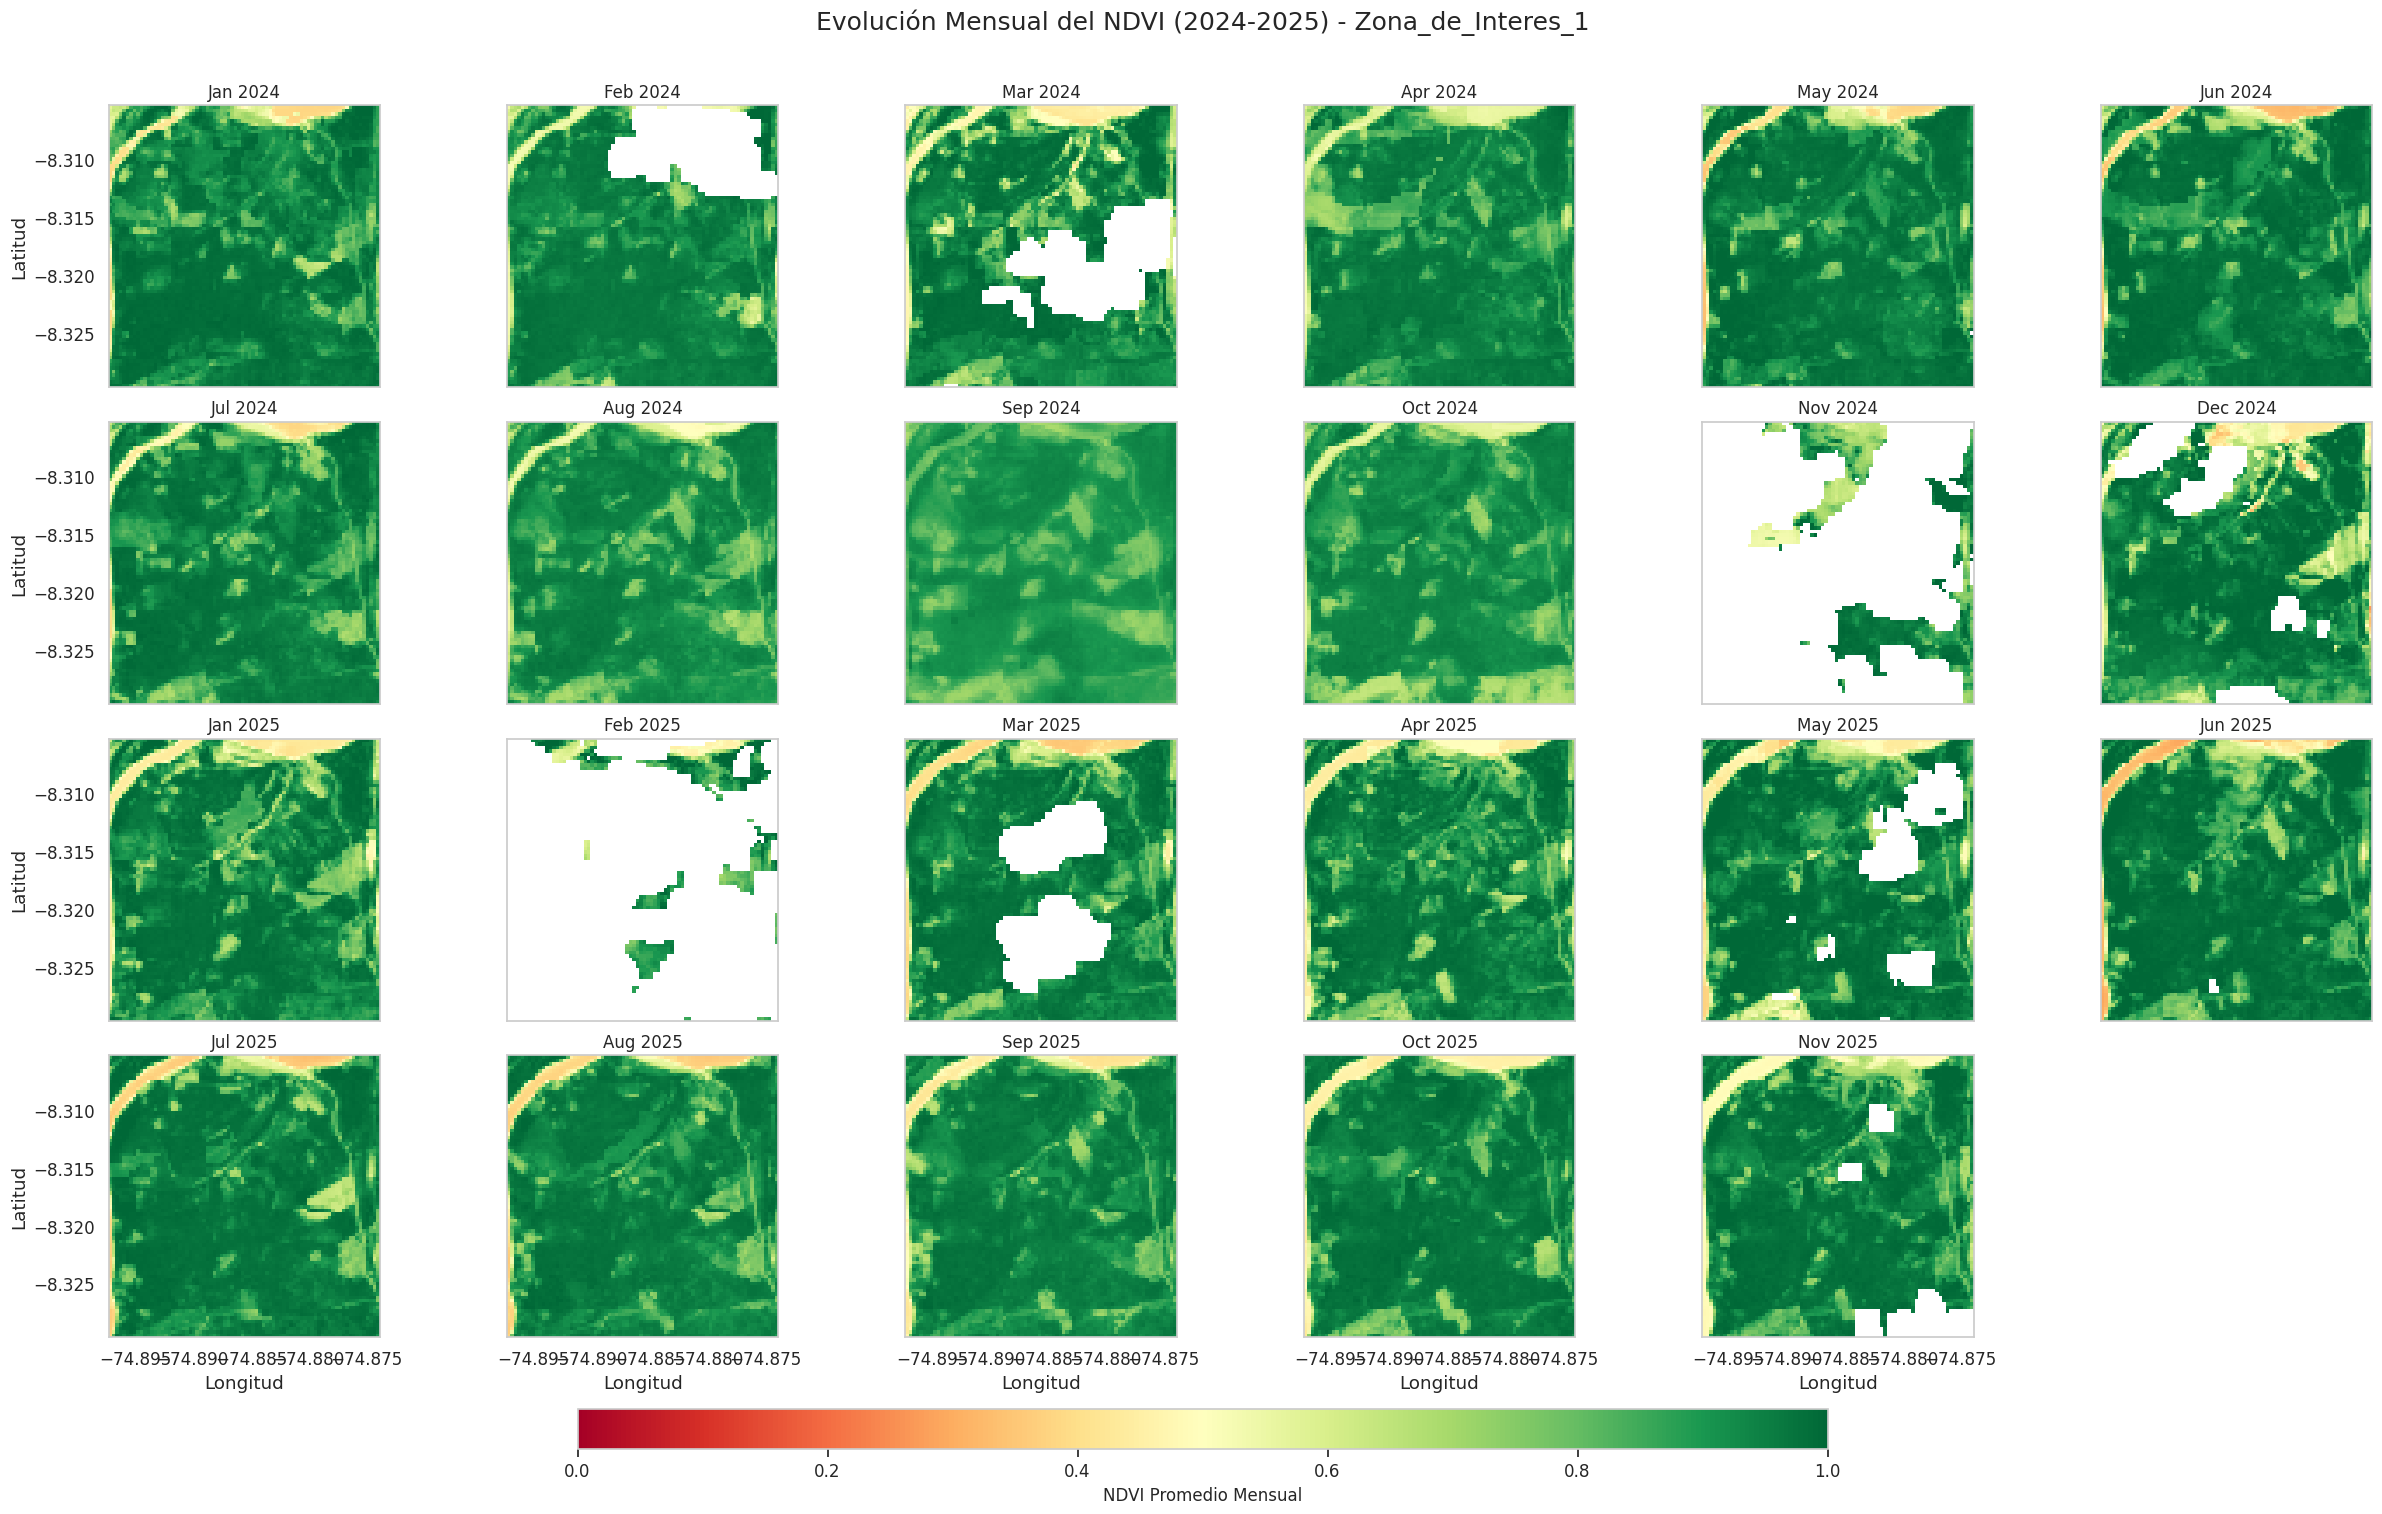


Exportando datos promedio mensuales para Zona_de_Interes_1...
Datos guardados como: NDVI_Promedio_Mensual_Zona_de_Interes_1.csv

--- 2. Generando gráfico de serie temporal (Estilo Mejorado) ---
Gráfico de serie temporal guardado como: Serie_Temporal_NDVI_Zona_de_Interes_1.png


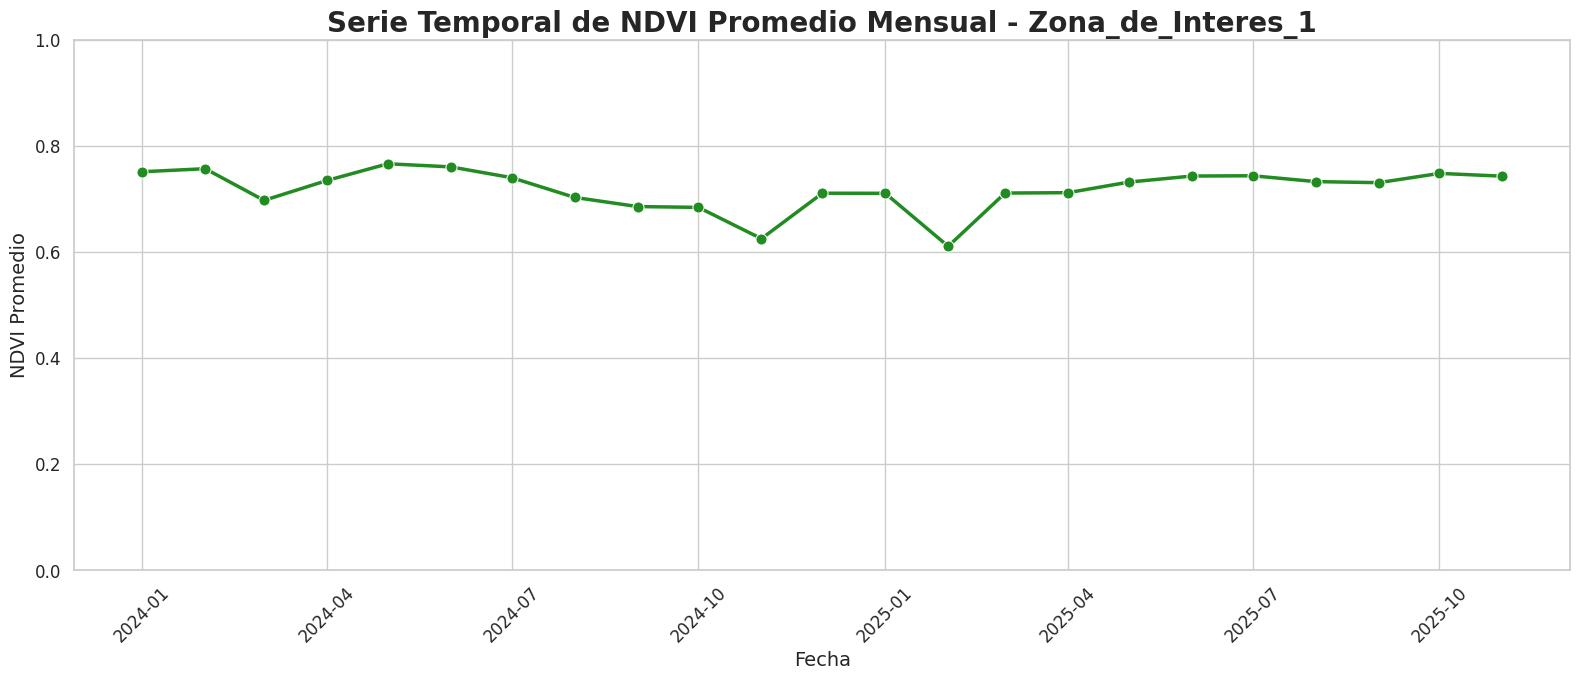


--- 3. Generando gráfico de Comparativa Anual ---
Gráfico de comparativa anual guardado como: Comparativa_Anual_NDVI_Zona_de_Interes_1.png


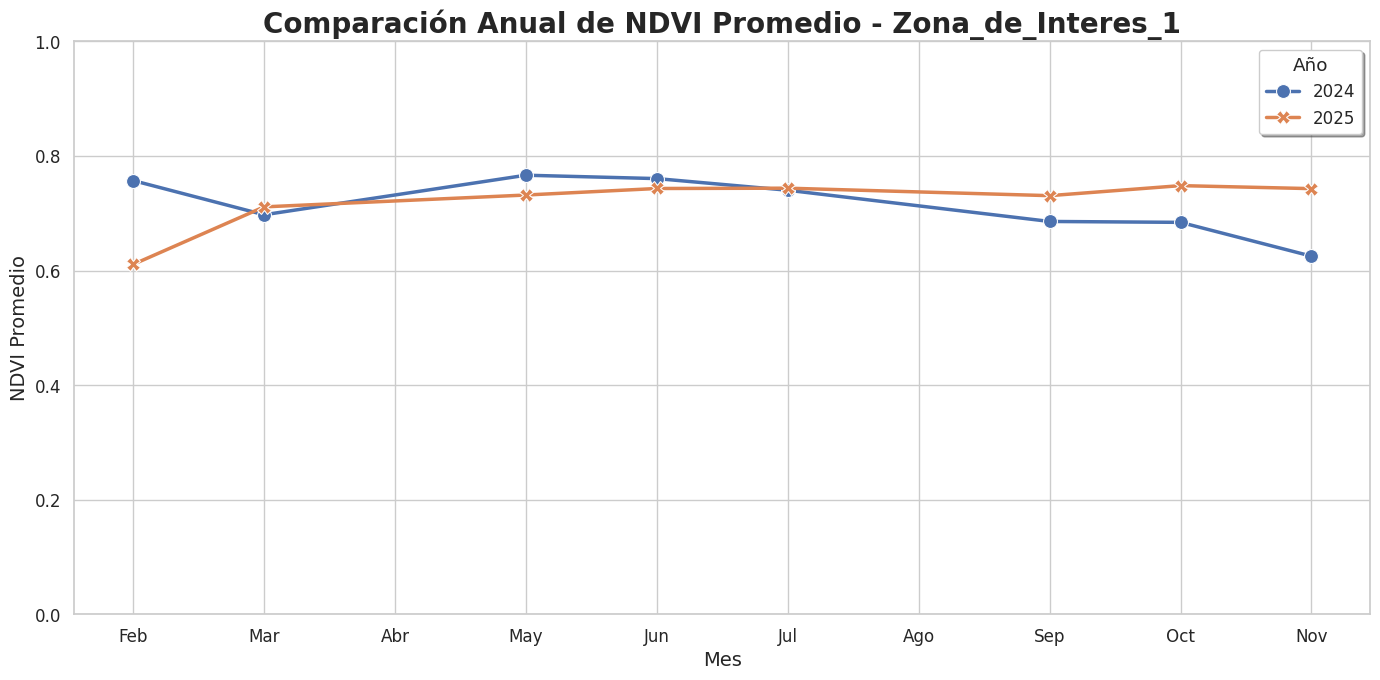


--- 4. Generando Boxplot de distribución mensual ---
Gráfico boxplot guardado como: Boxplot_Mensual_NDVI_Zona_de_Interes_1.png


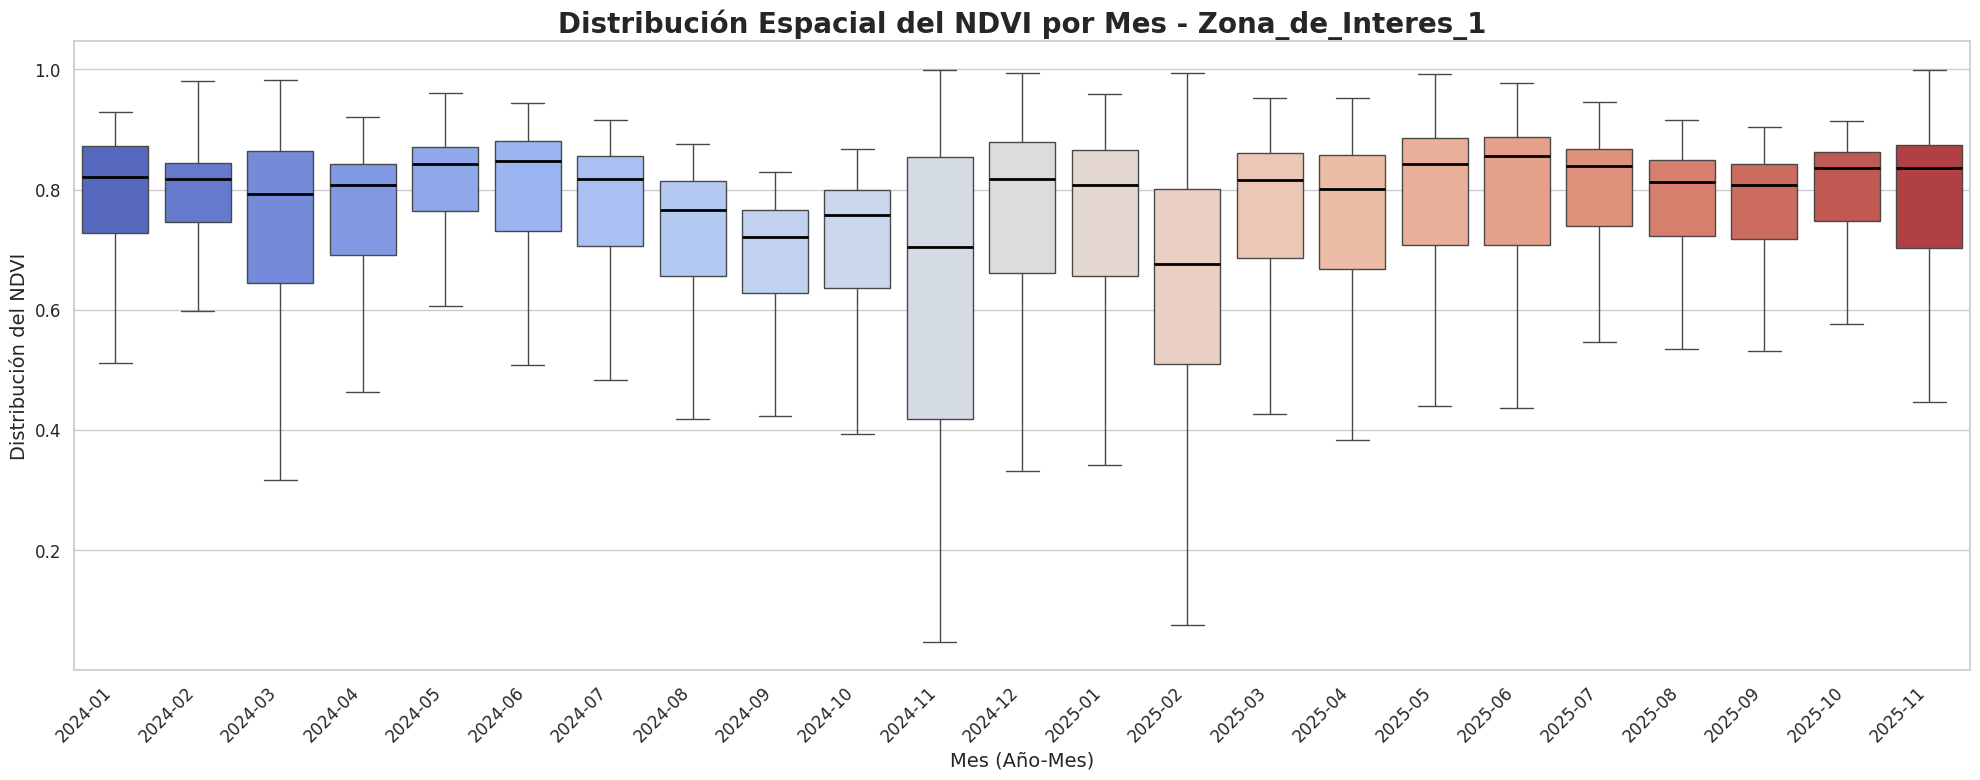


--- 5.1. Calculando y exportando LOS para 2024 ---
Mapa GeoTIFF guardado como: LOS_2024_Zona_de_Interes_1.tif
--- 5.2. Generando Mapa LOS para 2024 ---
Gráfico del mapa LOS guardado como: Mapa_LOS_2024_Zona_de_Interes_1.png


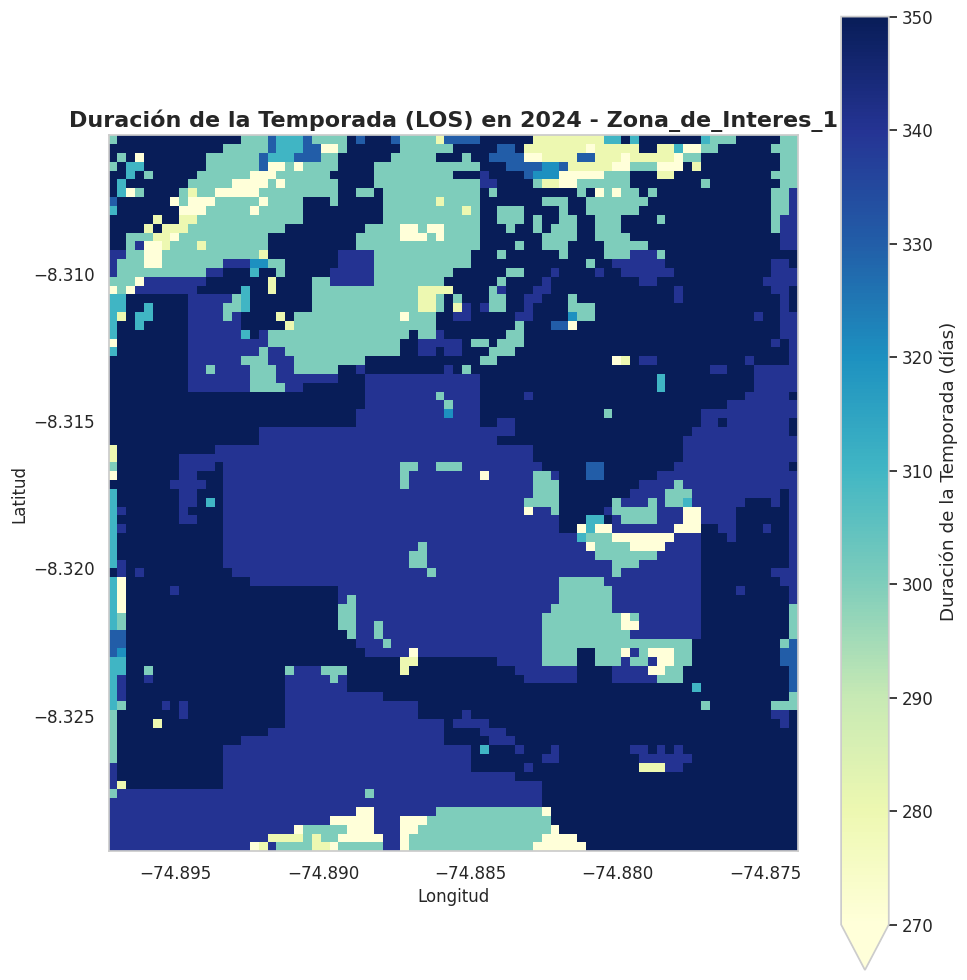

--- 5.3. Generando Histograma LOS para 2024 ---
Gráfico de histograma LOS guardado como: Histograma_LOS_2024_Zona_de_Interes_1.png


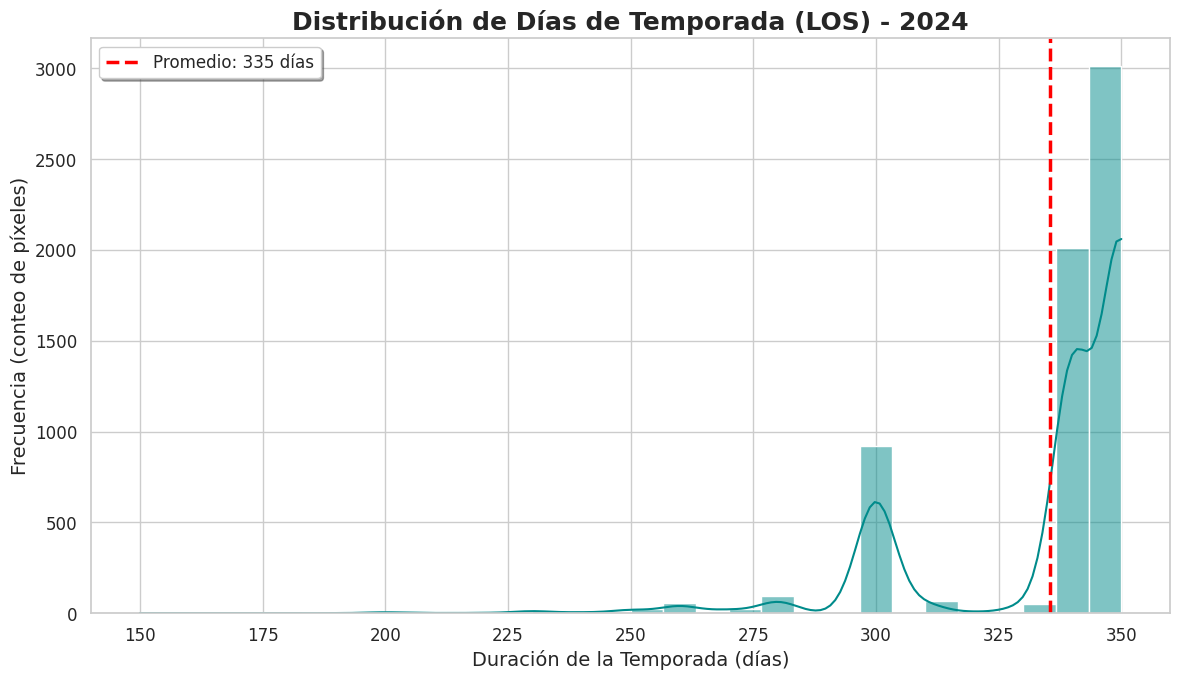


--- 5.1. Calculando y exportando LOS para 2025 ---
Mapa GeoTIFF guardado como: LOS_2025_Zona_de_Interes_1.tif
--- 5.2. Generando Mapa LOS para 2025 ---
Gráfico del mapa LOS guardado como: Mapa_LOS_2025_Zona_de_Interes_1.png


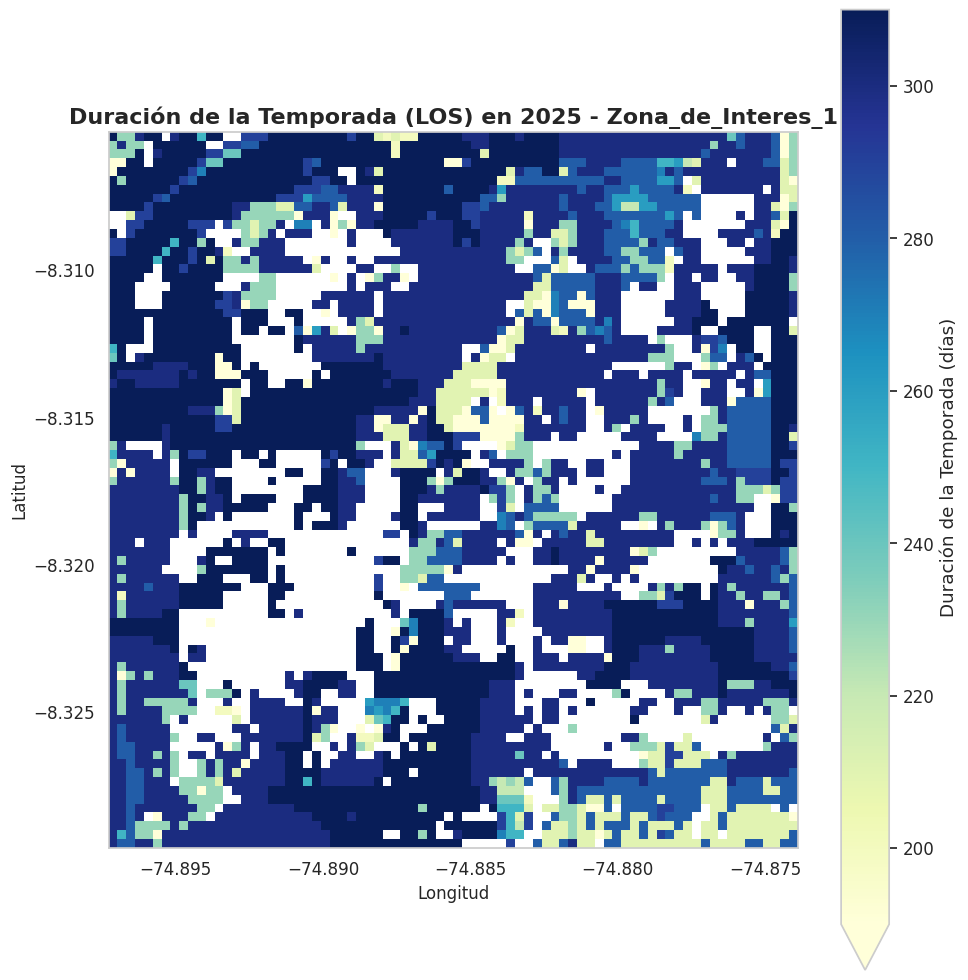

--- 5.3. Generando Histograma LOS para 2025 ---
Gráfico de histograma LOS guardado como: Histograma_LOS_2025_Zona_de_Interes_1.png


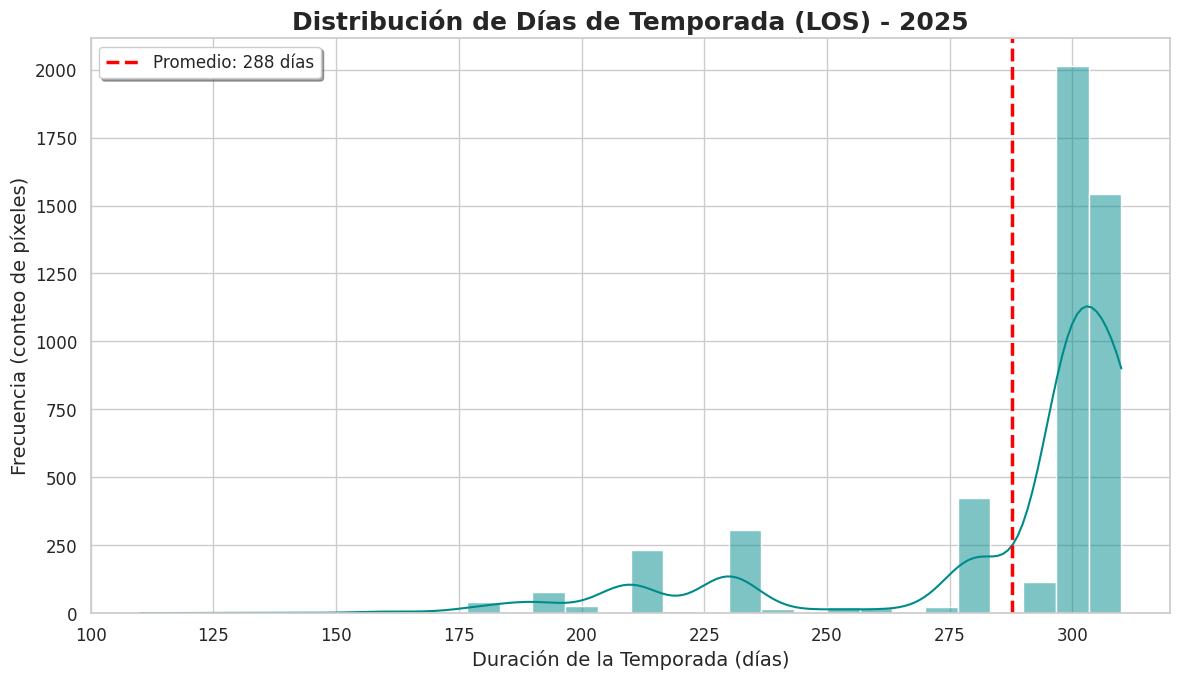


--- ANÁLISIS Y EXPORTACIÓN COMPLETADOS ---


In [5]:
# PASO 5: EJECUCIÓN DEL ANÁLISIS PARA LA ZONA ÚNICA
# ==============================================================================
# Restaurar los estilos de matplotlib por defecto al final (opcional)
try:
    analizar_y_exportar(roi=aoi, nombre_zona=nombre_zona)
    print("\n" + "="*80)
    print("--- ANÁLISIS Y EXPORTACIÓN COMPLETADOS ---")
finally:
    plt.rcdefaults() # Devuelve los estilos de matplotlib a la normalidad

In [7]:
import os
from google.colab import files
import time

# 1. Buscar todos los archivos .tif y .csv en el directorio actual
archivos_generados = [f for f in os.listdir('.') if f.endswith('.tif') or f.endswith('.csv')]

print(f"Archivos encontrados: {len(archivos_generados)}")

# 2. Descargar cada uno
if len(archivos_generados) > 0:
    for archivo in archivos_generados:
        print(f"Iniciando descarga de: {archivo} ...")
        try:
            files.download(archivo)
            # Pequeña pausa para evitar que el navegador bloquee descargas múltiples
            time.sleep(3)
        except Exception as e:
            print(f"Error al descargar {archivo}: {e}")
else:
    print("No se encontraron archivos generados. Revisa si el paso anterior se completó correctamente.")

Archivos encontrados: 3
Iniciando descarga de: NDVI_Promedio_Mensual_Zona_de_Interes_1.csv ...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Iniciando descarga de: LOS_2025_Zona_de_Interes_1.tif ...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Iniciando descarga de: LOS_2024_Zona_de_Interes_1.tif ...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>